In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from scipy import stats

In [4]:
# create dataset for outliers
np.random.seed(42)
normal_data = np.random.normal(50,10,100)
normal_data

array([54.96714153, 48.61735699, 56.47688538, 65.23029856, 47.65846625,
       47.65863043, 65.79212816, 57.67434729, 45.30525614, 55.42560044,
       45.36582307, 45.34270246, 52.41962272, 30.86719755, 32.75082167,
       44.37712471, 39.8716888 , 53.14247333, 40.91975924, 35.87696299,
       64.65648769, 47.742237  , 50.67528205, 35.75251814, 44.55617275,
       51.1092259 , 38.49006423, 53.75698018, 43.9936131 , 47.0830625 ,
       43.98293388, 68.52278185, 49.86502775, 39.42289071, 58.22544912,
       37.7915635 , 52.08863595, 30.40329876, 36.71813951, 51.96861236,
       57.3846658 , 51.71368281, 48.84351718, 46.98896304, 35.2147801 ,
       42.80155792, 45.39361229, 60.57122226, 53.4361829 , 32.36959845,
       53.24083969, 46.1491772 , 43.23078   , 56.11676289, 60.30999522,
       59.31280119, 41.60782477, 46.90787624, 53.31263431, 59.75545127,
       45.20825762, 48.14341023, 38.93665026, 38.03793376, 58.12525822,
       63.56240029, 49.27989878, 60.03532898, 53.61636025, 43.54

In [5]:
outliers = [150,200,250]
data = np.concatenate([normal_data, outliers])
df = pd.DataFrame({"value":data})
df.describe()

,value
count,103.000000
mean,53.360713
std,27.937209
min,23.802549
25%,44.185369
50%,49.279899
75%,55.279137
max,250.000000


Text(0.5, 1.0, 'Histogram with outliers')

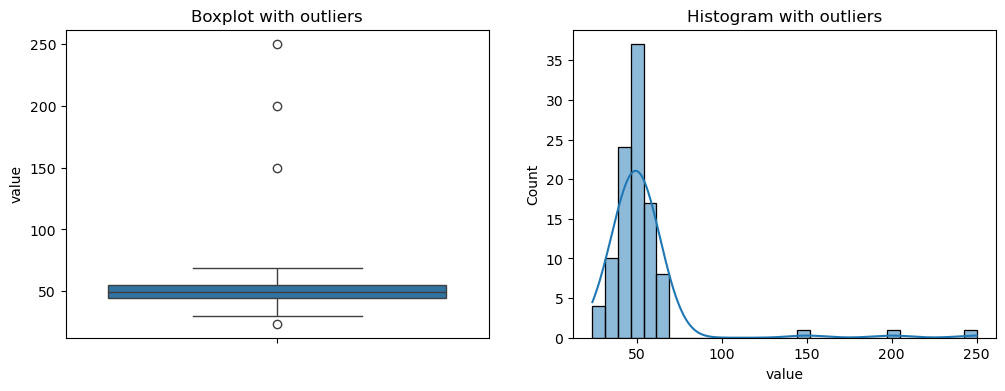

In [7]:
# plotting data

plt.figure(figsize = (12,4))
plt.subplot(1,2,1)
sns.boxplot(y = df['value'])
plt.title("Boxplot with outliers")
plt.subplot(1,2,2)
sns.histplot(df['value'], bins = 30, kde = True)
plt.title("Histogram with outliers")

In [10]:
# displaying outiers by detection

z_scores = np.abs(stats.zscore(df['value']))
df['z_outlier'] = z_scores > 3

#IQR
Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 - IQR
upper_bound = Q3 + 1.5 * IQR
df['iqr_outlier'] = (df['value'] < lower_bound)|(df['value'] > upper_bound)
display(df.tail(15))

,value,z_outlier,iqr_outlier
88,44.702398,False,False
89,55.132674,False,False
90,50.970775,False,False
91,59.686450,False,False
92,42.979469,False,False
93,46.723379,False,False
94,46.078918,False,False
95,35.364851,False,False
96,52.961203,False,False
97,52.610553,False,False


In [11]:
# removing outliers
#IQR method

df_removed = df[~df['iqr_outlier']]
df_removed

,value,z_outlier,iqr_outlier
0,54.967142,False,False
1,48.617357,False,False
2,56.476885,False,False
3,65.230299,False,False
4,47.658466,False,False
...,...,...,...
95,35.364851,False,False
96,52.961203,False,False
97,52.610553,False,False
98,50.051135,False,False


In [12]:
# Capping Outliers using (winsorization method)

df_capped  = df.copy()
df_capped['value'] = np.where(df_capped['value'] > upper_bound, upper_bound, np.where(df_capped['value'] < lower_bound, lower_bound, df_capped['value']))


Text(0.5, 1.0, 'Winsorization Removed outlier')

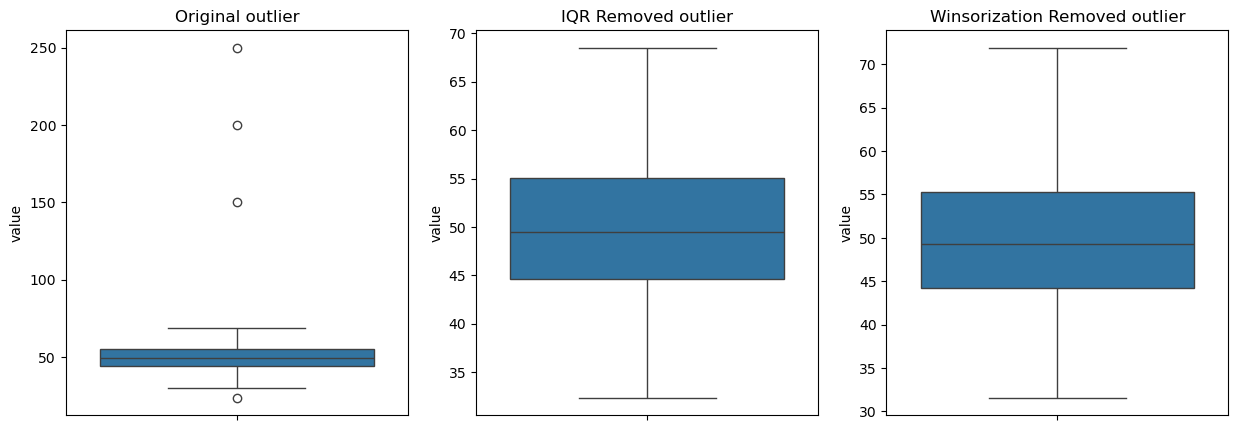

In [17]:
# visualization
fig,axes = plt.subplots(1,3, figsize = (15,5))
sns.boxplot(y = df['value'], ax = axes[0])
axes[0].set_title("Original outlier")

sns.boxplot(y = df_removed['value'], ax = axes[1])
axes[1].set_title("IQR Removed outlier")

sns.boxplot(y = df_capped['value'], ax = axes[2])
axes[2].set_title("Winsorization Removed outlier")